# SysVar 101

The full notebook can be found [here](https://gitlab.desy.de/itsaklid/sysvar/-/blob/main/examples/minimal_example.ipynb?ref_type=heads) 

### This notebook provides a minimal example on how to use SysVar.
### We will create Eigenvariations of our fitting variable based on the charged slow pion corrections in 2 reconstruction channels and for 2 templates in 15 bins

In [1]:
%reload_ext autoreload
%autoreload 2

### Attention: 

### Setting the SysVar Path

**Please update the path below to point to the location where you have installed your SysVar fork, then execute the cell.**

This step is currently necessary because the basf2 developers have renamed their `pidvar` class to `sysvar`, anticipating an early merge of the SysVar package into basf2.

If you are running with an environment sourced from CVMFS and have not executed the cell below, you will encounter the following error:

```
ModuleNotFoundError: No module named 'sysvar.utils'; 'sysvar' is not a package
```

**To avoid this error, set the correct path to your SysVar installation and run the cell.**

In [2]:
import sys
sys.path.insert(0,'{path_where_you_pip_installed_sysvar}/SysVar/src')

### Create a pseudo-dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sample_size = 2000
theta =  5.5
momentum_scaler =MinMaxScaler((0.05, 0.4))
momentum_scaler.fit(np.random.gamma(theta, 1.0, sample_size).reshape(-1, 1))
toy_df = pd.DataFrame(
    {
        "channel": np.random.randint(0, 2, sample_size), # Assume 4 reco channels,
        "template": np.random.randint(1, 3, sample_size), # Assume 2 templates, 1 = signal and 2 = BKG
        "slow_pi_p": momentum_scaler.transform(np.random.gamma(theta, 1.0, sample_size).reshape(-1, 1)).flatten(),
    }
)

toy_df["slow_pi_mcPDG"] =  np.random.choice([-211, 211], sample_size)
toy_df["slow_pi_PDG"] =  np.random.choice([-211, 211], sample_size)

toy_df.loc[toy_df.template == 1, "fit_variable1"] = np.random.exponential(0.2, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 1, "fit_variable2"] = np.random.normal(2.5, 0.3, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 1, "other_weight"] = np.random.normal(0.3, 0.04, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 2, "fit_variable1"] = np.random.power(1.5, len(toy_df[toy_df.template == 2]))
toy_df.loc[toy_df.template == 2, "fit_variable2"] = np.random.rayleigh(1.5, size = len(toy_df[toy_df.template == 2]))
toy_df.loc[toy_df.template == 2, "other_weight"] = np.random.normal(0.8, 0.1, len(toy_df[toy_df.template == 2]))

toy_df = toy_df.query("0 < fit_variable1 < 1")
toy_df = toy_df.query("1 < fit_variable2 < 4")
toy_df = toy_df.query("0.05 < slow_pi_p < 0.4")

toy_df["template"].replace(1, "signal", inplace = True)
toy_df["template"].replace(2, "bkg", inplace = True)


/var/folders/pv/0jgqndwd687_skyjt_y0d0n40000gn/T/ipykernel_22920/1716180670.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  toy_df["template"].replace(1, "signal", inplace = True)


### A minimal dataframe

In [4]:
toy_df

,channel,template,slow_pi_p,slow_pi_mcPDG,slow_pi_PDG,fit_variable1,fit_variable2,other_weight
0,0,signal,0.155094,-211,-211,0.041484,2.019546,0.239796
1,0,signal,0.130223,211,211,0.032454,2.241897,0.310907
2,0,signal,0.212993,211,211,0.059764,2.213252,0.288747
3,1,signal,0.107134,-211,-211,0.136591,2.721423,0.248613
4,1,bkg,0.105126,211,211,0.715123,2.170915,0.652969
...,...,...,...,...,...,...,...,...
1994,1,signal,0.125031,211,-211,0.227572,2.457636,0.275814
1995,0,signal,0.140069,-211,-211,0.036787,2.287677,0.302884
1996,0,bkg,0.171060,211,211,0.340219,2.180832,0.817238
1997,1,bkg,0.186731,211,211,0.452914,1.279273,0.815862


### Let's plot what we have

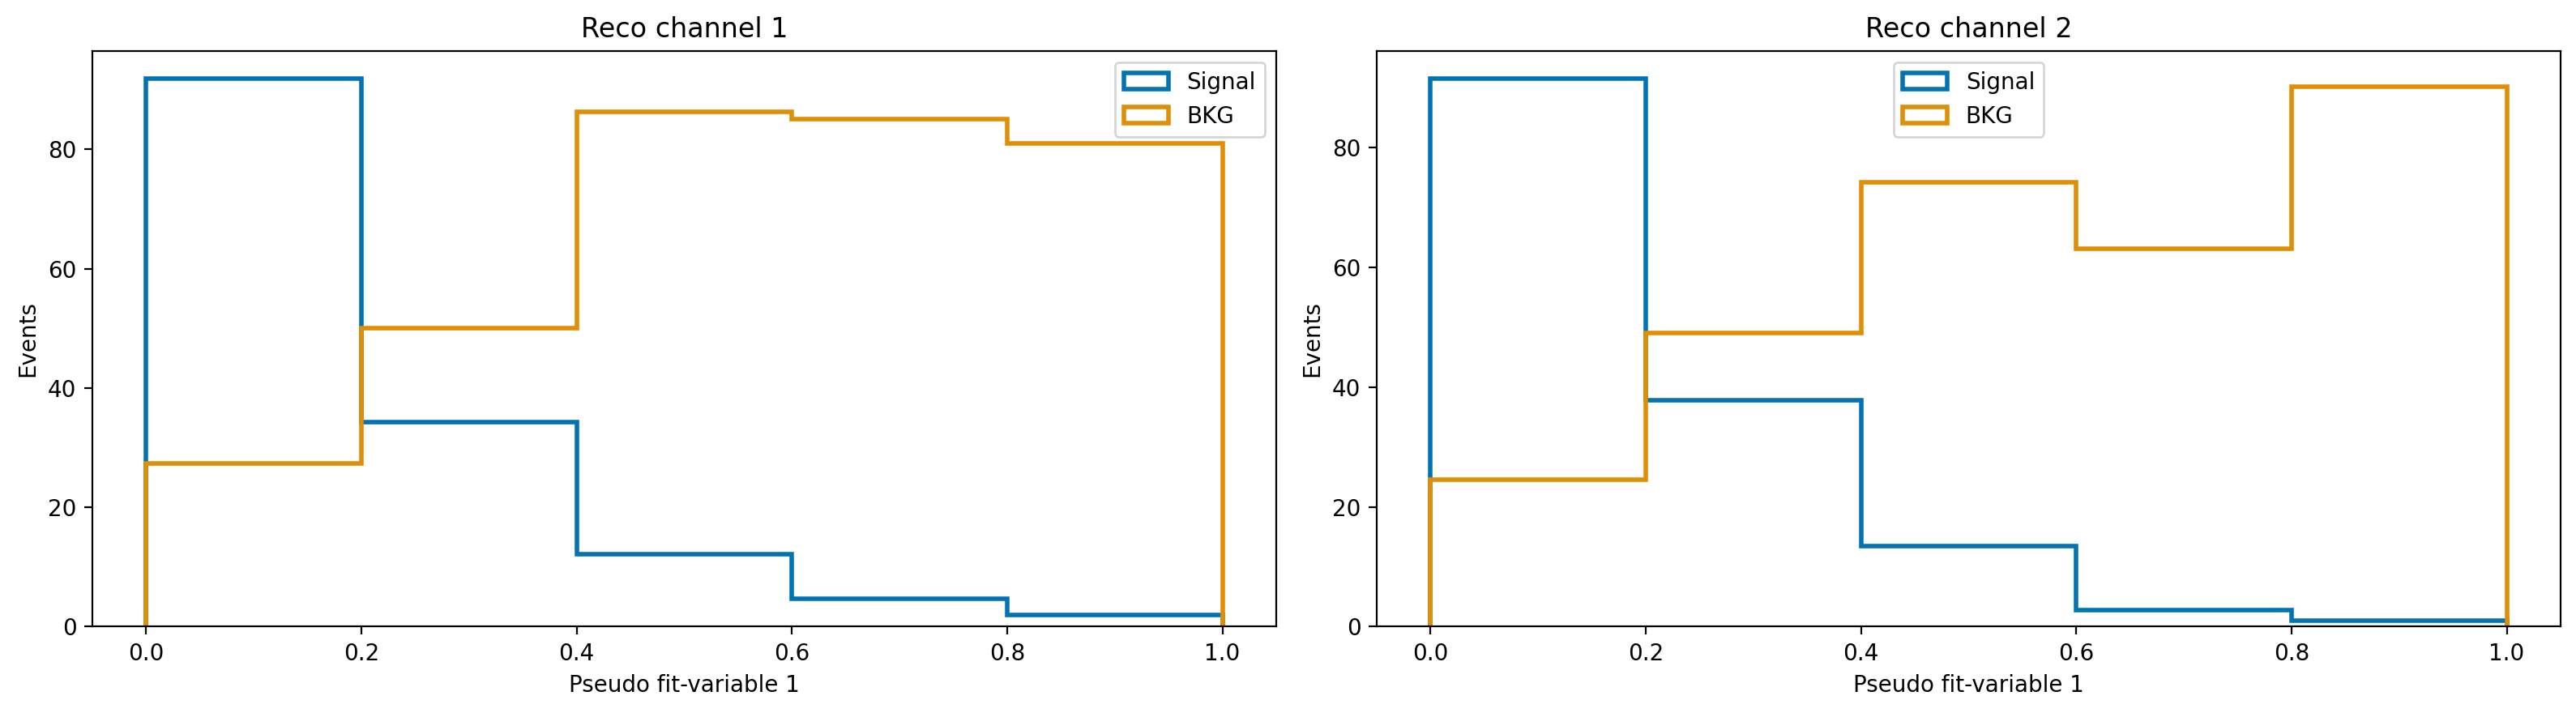

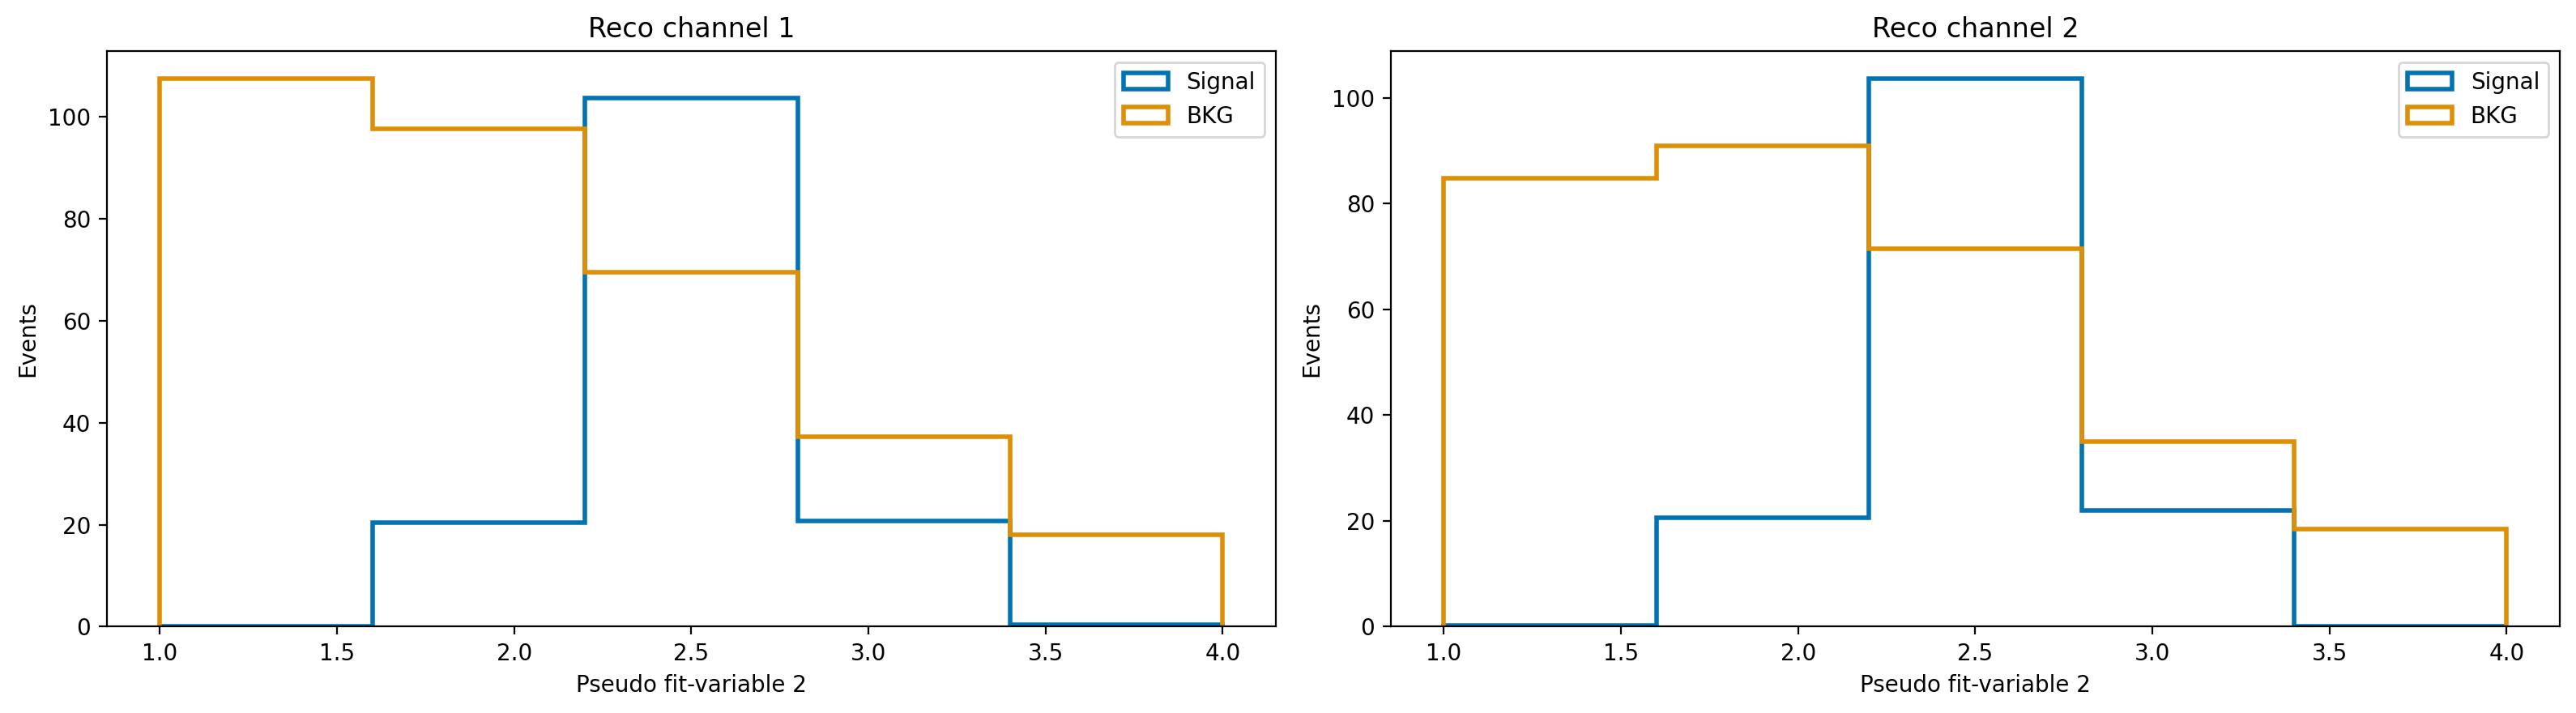

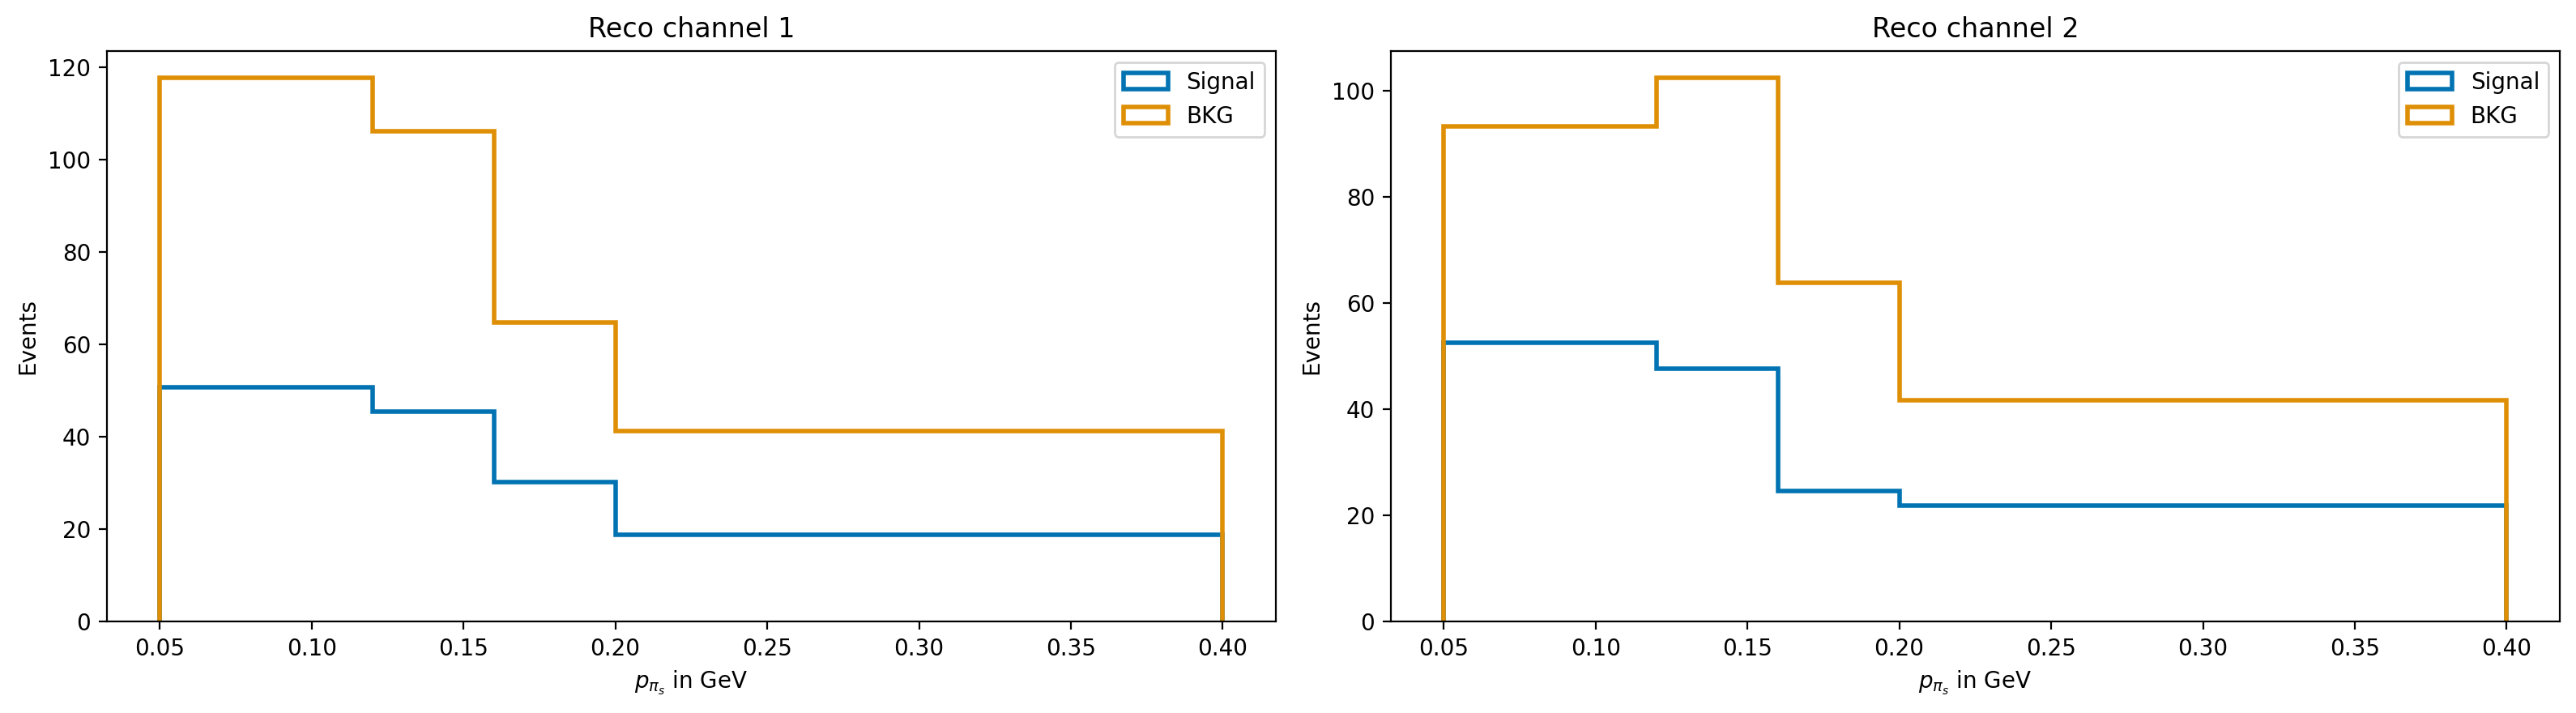

In [5]:
PALETTE = sns.color_palette("colorblind")


def plot_var_in_2_channels(column_name, xlabel, bins, scope):

    fig, ax = plt.subplots(1, 2, figsize = (16, 4.5), dpi = 200)

    for i, c in enumerate(toy_df.channel.value_counts().keys()):
        for j, t in enumerate(toy_df.template.value_counts().keys()):
            tmp_df = toy_df.query(f"channel == {c} & template == '{t}'")
            ax[i].hist(
                tmp_df[column_name],
                weights=tmp_df["other_weight"],
                histtype = "step",
                label = "Signal" if t == "signal" else "BKG",
                bins = bins,
                range = scope,
                linewidth = 2,
                color = PALETTE[j]
            )
        ax[i].legend()
        ax[i].set_xlabel(xlabel)
        ax[i].set_ylabel("Events")
        ax[i].set_title(f"Reco channel {i+1}")


plot_var_in_2_channels("fit_variable1", "Pseudo fit-variable 1", bins = 5, scope = (0,1))
plt.tight_layout()
#plt.savefig("pseudofit1.png", dpi = 200)
plot_var_in_2_channels("fit_variable2", "Pseudo fit-variable 2", bins = 5, scope = (1,4))
plt.tight_layout()
#plt.savefig("pseudofit2.png", dpi = 200)
plot_var_in_2_channels("slow_pi_p", r"$p_{\pi_{s}}$ in GeV", bins = [0.05, 0.12, 0.16, 0.2, 0.4], scope = (0, 0.4))
plt.tight_layout()

Let’s assume that the slow–pion efficiency differs between MC and data, so we need to correct the MC.

Further assume that this efficiency correction is provided in bins of the slow–pion momentum. These corrections will need to be supplied to SysVar (details follow in the next sections).

For now, we will illustrate the procedure using a pseudo-correction defined in three momentum bins for the slow pion.

These correction weights may be partially correlated across bins, due to both statistical and systematic uncertainties.
Events with slow pions in different momentum bins can populate different bins of the signal-extraction observables, and therefore the induced correlation between those templates is not trivial to compute by hand.

Our task is to *propagate the correlations from the correction-weight space (momentum bins) to the signal-extraction space (template bins) in a consistent way*.

### Now let's add slow pion weights to the dataframe

### Information necessary in the dataframe for charged slow pion:
Looking at the config file for `charged_slow_pion` corrections 

1. dependent variable: `p`
2. extra_cuts: `PDG`

For Belle II analyses, these are the [basf2](https://software.belle2.org/light-2509-fornax/sphinx/index.html) variable information required in the dataframe for this correction to work. A prefix can be chosen to distinguish between different particles or also can be provided as a list of prefices. Here a prefix `"slow_pi"` is provided. This requires the dataframe to contain the variables `slow_pi_p`, `slow_pi_PDG`. A weightname for the corresponding correction is required and if a prefix is provided it will be prepended to that name. In the example, we add a variable called `slow_pi_charged_weight`.


In [6]:
from sysvar import add_weights_to_dataframe

add_weights_to_dataframe(
    df = toy_df,
    systematic= "charged_slow_pi",
    MC_production= "sysvar_101",
    prefix= "slow_pi",
    weightname ="charged_weight",
    #overwrite: False,
    #Nvar: 0
)
toy_df

INFO : read_corrections: 392 :  Loading correction values from config array.
INFO : add_weights_to_dataframe: 86 :  slow_pi_charged_weight does not exist. Adding it to dataframe


,channel,template,slow_pi_p,slow_pi_mcPDG,slow_pi_PDG,fit_variable1,fit_variable2,other_weight,slow_pi_charged_weight
0,0,signal,0.155094,-211,-211,0.041484,2.019546,0.239796,0.989
1,0,signal,0.130223,211,211,0.032454,2.241897,0.310907,0.989
2,0,signal,0.212993,211,211,0.059764,2.213252,0.288747,1.000
3,1,signal,0.107134,-211,-211,0.136591,2.721423,0.248613,0.977
4,1,bkg,0.105126,211,211,0.715123,2.170915,0.652969,0.977
...,...,...,...,...,...,...,...,...,...
1994,1,signal,0.125031,211,-211,0.227572,2.457636,0.275814,0.989
1995,0,signal,0.140069,-211,-211,0.036787,2.287677,0.302884,0.989
1996,0,bkg,0.171060,211,211,0.340219,2.180832,0.817238,0.943
1997,1,bkg,0.186731,211,211,0.452914,1.279273,0.815862,0.943


If you try again, then SysVar will complain. In order to overwrite an existing weight, set the relevant argument to True

In [7]:
add_weights_to_dataframe(
    df = toy_df,
    systematic= "charged_slow_pi",
    MC_production= "sysvar_101",
    prefix= "slow_pi",
    weightname ="charged_weight",
    overwrite= False
)

INFO : read_corrections: 392 :  Loading correction values from config array.


Now we create the total weight of the analysis

In [8]:
toy_df["total_weight"] = toy_df[["other_weight", "slow_pi_charged_weight"]].product(axis = 1)

### Define the configurations for the Eigen decomposition


### Instructions for the SysVar Configuration File

This configuration file is the primary interface for communicating with SysVar. Your entire analysis setup should be encoded here.

#### Parameters

- `output_filepath`:  
  The path where both nominal templates and all template variations will be saved. Currently, only root files are supported.

- `reco_channel_id_column`:  
  The name of the column in your dataframe that distinguishes different reconstruction channels to be fitted separately but simultaneously.

- `reco_channels`:  
  A dictionary mapping custom channel names (as keys) to lists of values to be found in the `reco_channel_id_column`.

- `template_id_column`:  
  The name of the column in your dataframe that distinguishes different templates.

- `templates`:  
  A list of template names. These should correspond to values found in the `template_id_column` of your dataframe.

- `total_weight`:  
  The total weight to use when creating nominal templates for your analysis.

- `MC_prod`:  
  The Belle II MC campaign. Currently, only `MC15rd` is supported.

- `Nvar`:  
  The number of weight variations to generate.

- `bins`:  
  A nested dictionary defining the binning for each channel and variable. Both 1D and ND histogram projections are supported.

- `systematics`:  
  A nested dictionary. Each top-level key corresponds to a systematic name. For every systematic entry, the following fields must be provided:  
    - There should be a corresponding YAML file in the configs (see [configs/MC15rd](https://gitlab.desy.de/itsaklid/sysvar/-/tree/main/configs/MC15rd?ref_type=heads)).
    - The key `weight` should contain the name of the column with the weight associated with this systematic.
    - `prefices`: A string or list of strings to prepend to the weight name to build the column name present in the dataframe.
    - `reco_channels`: Specify a list of channels (as strings) to include or exclude in the systematic variation. If both are `None`, all channels will be affected.
    - `templates`: Specify a list of templates (as strings) to include or exclude in the systematic variation. Defaults to `None` (all templates affected).

---

Below you can see the configuration file that corresponds to this mininal example

In [9]:
from sysvar.utils import read_yaml

settings = read_yaml("study_setup", "sysvar_101")
settings

{'output_filepath': './test_output.root',
 'reco_channel_id_column': 'channel',
 'reco_channels': {'channel1': [0], 'channel2': [1]},
 'template_id_column': 'template',
 'templates': ['signal', 'bkg'],
 'total_weight': 'total_weight',
 'MC_prod': 'sysvar_101',
 'Nvar': 500,
 'bins': {'channel1': {'fit_variable1': [0, 0.2, 0.4, 0.6, 0.8, 1],
   'fit_variable2': [1, 2, 3, 4]},
  'channel2': {'fit_variable1': [0, 0.2, 0.4, 0.6, 0.8, 1],
   'fit_variable2': [1, 2, 3, 4]}},
 'systematics': {'charged_slow_pi': {'weight': 'charged_weight',
   'prefices': 'slow_pi',
   'reco_channels': {'include': ['channel1', 'channel2'], 'exclude': None},
   'templates': ['signal', 'bkg']},
  'BF_101': {'weight': 'BF_weight',
   'prefices': 'slow_pi',
   'reco_channels': {'include': ['channel1', 'channel2'], 'exclude': None},
   'templates': ['signal']}}}

### First let's save the nominal templates. 
This should always be the first step! It should always be prefered that the nominal histograms are saved before any variations in order to avoid problems with uproot's behavior when saving and updating files

In [10]:
from sysvar import save_nominal_templates
nominal_templates_handler = save_nominal_templates(toy_df, settings)

INFO : save_nominal_templates: 293 :  Recreate file with uproot: ./test_output.root
INFO : create_templates: 184 :  ########## Reco channel: channel1 ##########
INFO : create_templates: 215 :  Building TemplateND for signal from 486 events
INFO : create_templates: 215 :  Building TemplateND for bkg from 414 events
INFO : create_templates: 184 :  ########## Reco channel: channel2 ##########
INFO : create_templates: 215 :  Building TemplateND for signal from 489 events
INFO : create_templates: 215 :  Building TemplateND for bkg from 374 events
INFO : save_nominal_templates: 301 :  ##################################################
INFO : save_nominal_templates: 302 :  ########## Reco channel: channel1 ##########
INFO : save_nominal_templates: 305 :  ##################################################
INFO : save_nominal_templates: 309 :  Saving Nominal MC template signal in TBranch: channel1/signal/Nominal
INFO : save_nominal_templates: 309 :  Saving Nominal MC template bkg in TBranch: ch

### Let's now perform the eigendecomposition. 
The eigendecompose helper function will return an object which is the only input needed to use the rest of the API

In [11]:
from sysvar import eigendecompose

egd = eigendecompose(
    df = toy_df,
    settings = settings,
    syst_effect = "charged_slow_pi",
    #criterion: "max_differences",
    #prc: 0.005,
    #save_variations: False
)

INFO : read_corrections: 392 :  Loading correction values from config array.
INFO : create_templates: 184 :  ########## Reco channel: channel1 ##########
INFO : create_templates: 215 :  Building TemplateND for signal from 486 events
INFO : create_templates: 215 :  Building TemplateND for bkg from 414 events
INFO : create_templates: 184 :  ########## Reco channel: channel2 ##########
INFO : create_templates: 215 :  Building TemplateND for signal from 489 events
INFO : create_templates: 215 :  Building TemplateND for bkg from 374 events
INFO : vary_templates: 144 :  ########## Reco channel: channel1 ##########
INFO : vary_templates: 158 :  Adding variations to signal template
INFO : vary_templates: 158 :  Adding variations to bkg template
INFO : vary_templates: 144 :  ########## Reco channel: channel2 ##########
INFO : vary_templates: 158 :  Adding variations to signal template
INFO : vary_templates: 158 :  Adding variations to bkg template
Building partial covariances: 100%|██████████| 

If the save_variations option is enabled, the eigenvariations for all templates are written to `./test_output.root`. The structure of this file matches the format expected by cabinetry for building a pyhf model.

**NOTE**: `save_nominal_templates` recreates a root file, `save_template_variations` updates an existing root file. So it is very imporant that you first save the nominal templates and only afterwards the template variations.

### Examine the correlation matrix

This is the analysis correlation matrix. It is the corresponding covariance matrix that we're diagonalizing to get the eigenvariations.

The dimensions here are (N_channels * N_templates * Nbins). 

In this case 2x2x15 = 60

/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


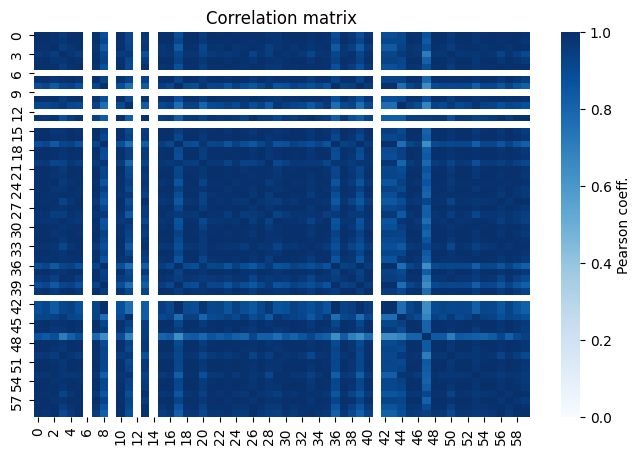

In [12]:
from sysvar import plot_analysis_corr_matrix
fig, ax= plot_analysis_corr_matrix(egd)

The empty rows and columns corresponds to bins with low statistics or zero expectation values in the fit variables. In our case, this comes from the signal template as can be seen in the plots at the begining of this notebook.

### Visualize how many of eigenvariations are important

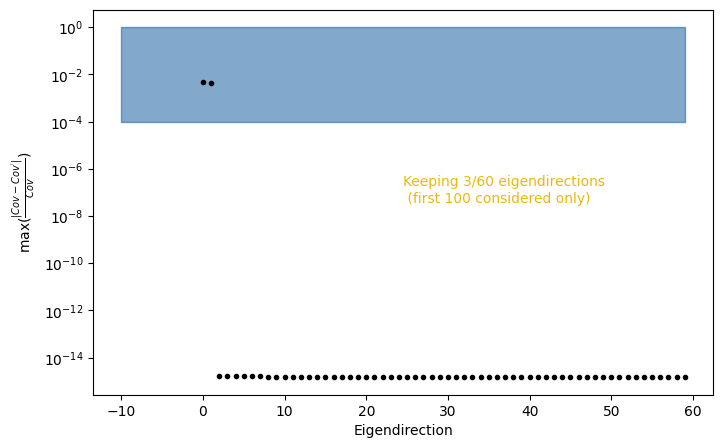

In [13]:
from sysvar import plot_cov_diff
fig, ax= plot_cov_diff(egd, save=False, filename = "test_figure")

This truncation is only an initial estimate of how many eigenvariations are needed to preserve the analysis precision.
By default, SysVar determines this by reconstructing the covariance matrix from the eigenvectors and comparing it to the original covariance.
Eigenvectors are added one-by-one until the maximum element-wise normalised difference between the reconstructed covariance and the original becomes smaller than the precision (`prc`) specified by the user when calling `eigendecompose`.
This is still an approximation — and analysts must validate it for their own use case.

A more physics-oriented cross-check is to add the eigenvariations saved by SysVar as nuisance parameters in the fit one-by-one and monitor the uncertainty of the parameter of interest (e.g. on an Asimov dataset).
When adding one more eigenvariation no longer changes the uncertainty, you have reached the number of relevant eigenvariations.

Note however: if you have already included all eigendirections saved by SysVar and the uncertainty on the parameter of interest still changes, then you should reduce the `prc` value (i.e. require a tighter precision) and repeat the eigendecomposition and validation.

The next sections detail the different types of corrections that SysVar provides, and how analysts can implement them in their analyses.